In [50]:
import pandas as pd

In [51]:
file_path = "yellow_tripdata_2023-01.parquet"

In [52]:
df = pd.read_parquet(file_path)

In [53]:
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

--- Dataset Shape ---
Rows: 3066766, Columns: 19


In [54]:
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object


In [55]:
print("\n--- Null Counts ---")
print(df.isnull().sum())


--- Null Counts ---
VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
RatecodeID               71743
store_and_fwd_flag       71743
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     71743
airport_fee              71743
dtype: int64


In [56]:
df_cleaned = df.copy()

In [57]:
df_cleaned['duration_minutes'] = (df_cleaned['tpep_dropoff_datetime'] - df_cleaned['tpep_pickup_datetime']).dt.total_seconds() / 60.0

In [58]:
initial_rows = len(df_cleaned)

In [59]:
df_cleaned = df_cleaned[
    (df_cleaned['tpep_pickup_datetime'] >= '2023-01-01 00:00:00') & 
    (df_cleaned['tpep_pickup_datetime'] <= '2023-01-31 23:59:59') &
    (df_cleaned['duration_minutes'] > 0.5) & (df_cleaned['duration_minutes'] <= 180.0) &
    (df_cleaned['trip_distance'] > 0.0) & (df_cleaned['trip_distance'] <= 100.0) &
    (df_cleaned['fare_amount'] >= 3.00) & 
    (df_cleaned['total_amount'] > 0.0) &
    (df_cleaned['passenger_count'] >= 1) & (df_cleaned['passenger_count'] <= 6)
]

In [60]:
print(f"Cleaned dataset. Kept {len(df_cleaned)} out of {initial_rows} rows.")

Cleaned dataset. Kept 2876094 out of 3066766 rows.


In [61]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [62]:
import matplotlib.pyplot as plt

In [63]:
import matplotlib.ticker as mticker

In [64]:
import numpy as np

In [65]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.day_name()
df['trip_duration_min'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60
df['avg_speed_mph'] = df['trip_distance'] / (df['trip_duration_min'] / 60)
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance']

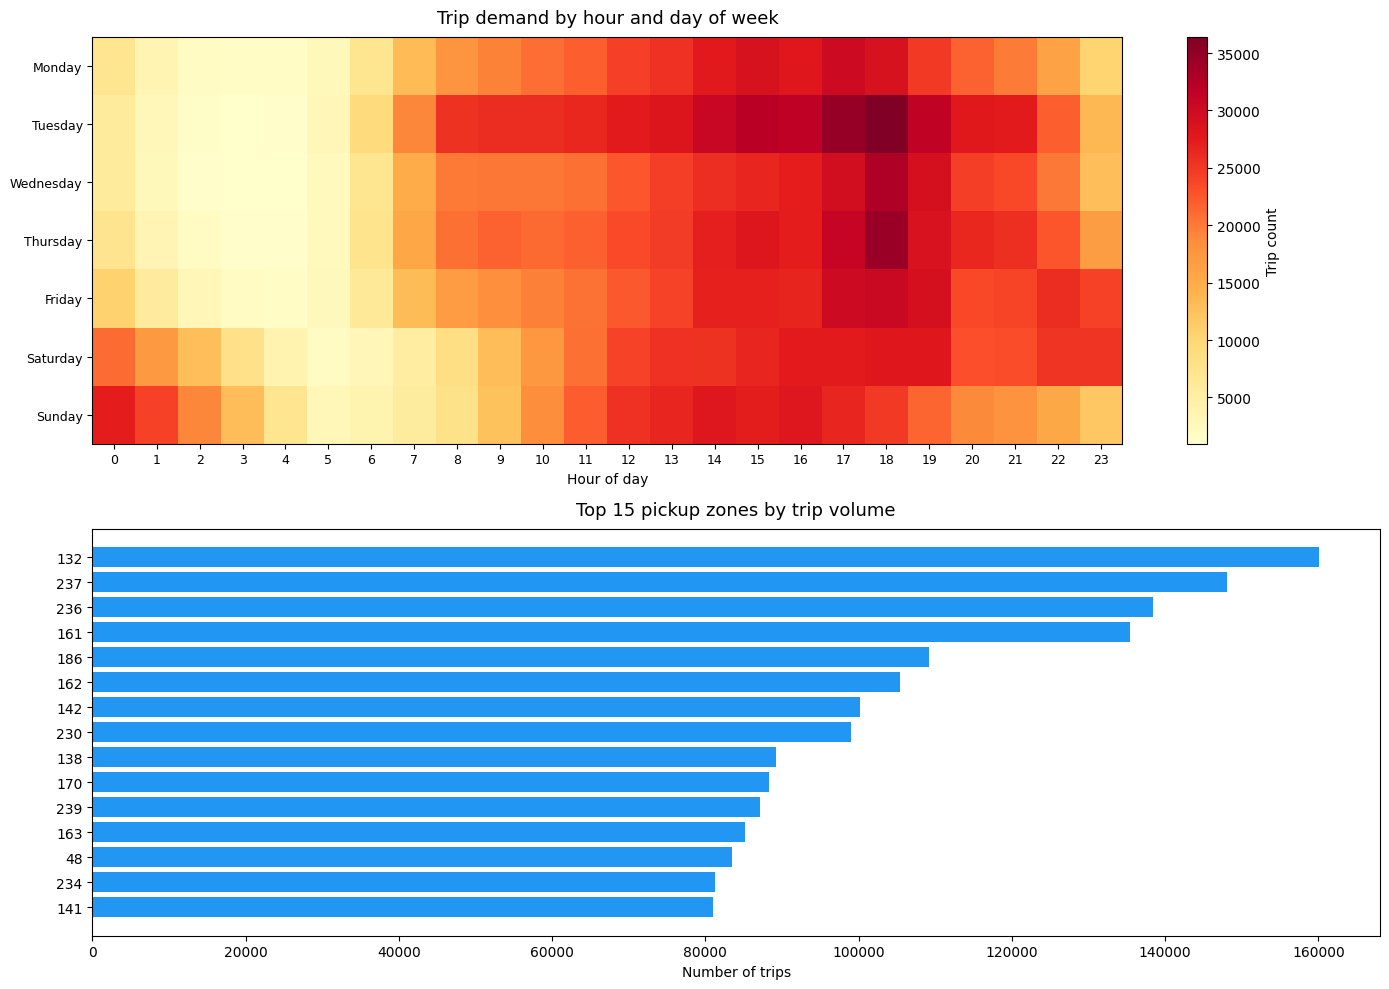

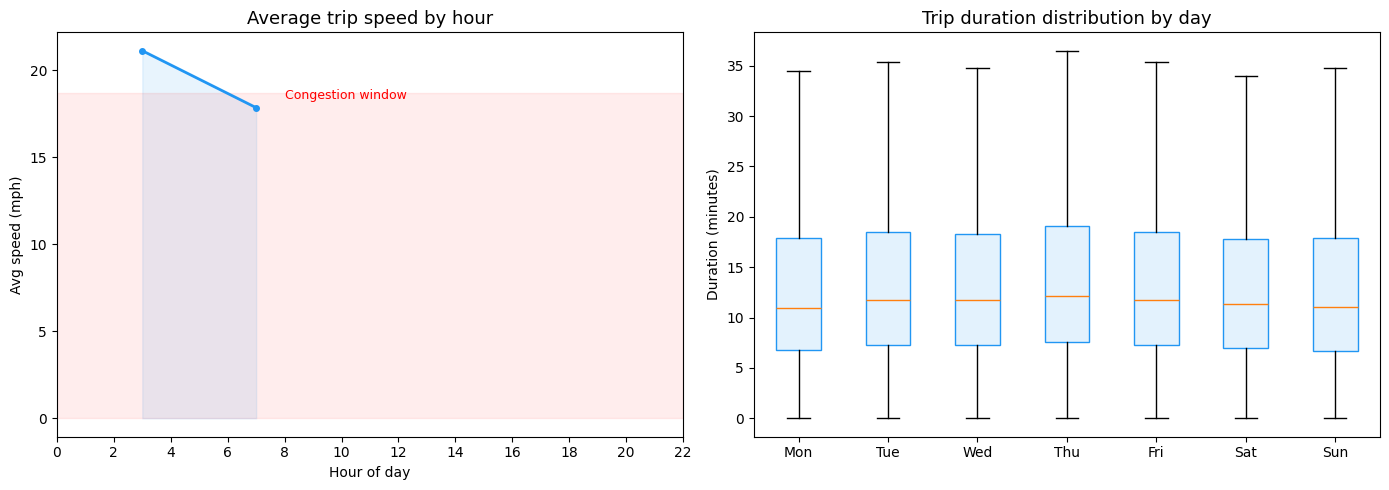

In [66]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = df.groupby(['pickup_dayofweek','pickup_hour']).size().unstack()
heatmap_data = heatmap_data.reindex(day_order)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
im = axes[0].imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')
axes[0].set_xticks(range(24))
axes[0].set_xticklabels(range(24), fontsize=9)
axes[0].set_yticks(range(7))
axes[0].set_yticklabels(day_order, fontsize=9)
axes[0].set_title('Trip demand by hour and day of week', fontsize=13, pad=10)
axes[0].set_xlabel('Hour of day')
plt.colorbar(im, ax=axes[0], label='Trip count')
top_zones = df['PULocationID'].value_counts().head(15)
axes[1].barh(top_zones.index.astype(str), top_zones.values, color='#2196F3')
axes[1].set_title('Top 15 pickup zones by trip volume', fontsize=13, pad=10)
axes[1].set_xlabel('Number of trips')
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig('q1_demand.png', dpi=150, bbox_inches='tight')
plt.show()

hourly = df.groupby('pickup_hour').agg(
    avg_speed=('avg_speed_mph', 'mean'),
    avg_duration=('trip_duration_min', 'mean'),
    trip_count=('trip_distance', 'count')
).reset_index()

hourly['avg_speed'] = pd.to_numeric(hourly['avg_speed'], errors='coerce').replace([np.inf, -np.inf], np.nan)
hourly = hourly.dropna(subset=['avg_speed'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hourly['pickup_hour'], hourly['avg_speed'], 
             color='#2196F3', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(hourly['pickup_hour'], hourly['avg_speed'], alpha=0.1, color='#2196F3')
axes[0].set_title('Average trip speed by hour', fontsize=13)
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Avg speed (mph)')
axes[0].set_xticks(range(0, 24, 2))
speed_q25 = hourly['avg_speed'].quantile(0.25)
speed_min = hourly['avg_speed'].min()
axes[0].axhspan(0, speed_q25, alpha=0.07, color='red')
axes[0].annotate('Congestion window', xy=(8, speed_min + 0.5), 
                 fontsize=9, color='red')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
duration_by_day = []
final_labels = []
for d in day_order:
    day_data = df[df['pickup_dayofweek'] == d]['trip_duration_min']
    clean_series = pd.to_numeric(day_data, errors='coerce')
    clean_array = clean_series.replace([np.inf, -np.inf], np.nan).dropna().values
    
    
    if len(clean_array) > 0 and np.max(clean_array) != np.min(clean_array):
        duration_by_day.append(clean_array)
        final_labels.append(d[:3])

bp = axes[1].boxplot(duration_by_day, tick_labels=final_labels, 
                      patch_artist=True, showfliers=False)

for patch in bp['boxes']:
    patch.set_facecolor('#E3F2FD')
    patch.set_edgecolor('#2196F3')

axes[1].set_title('Trip duration distribution by day', fontsize=13)
axes[1].set_ylabel('Duration (minutes)')

plt.tight_layout()
plt.savefig('q2_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()


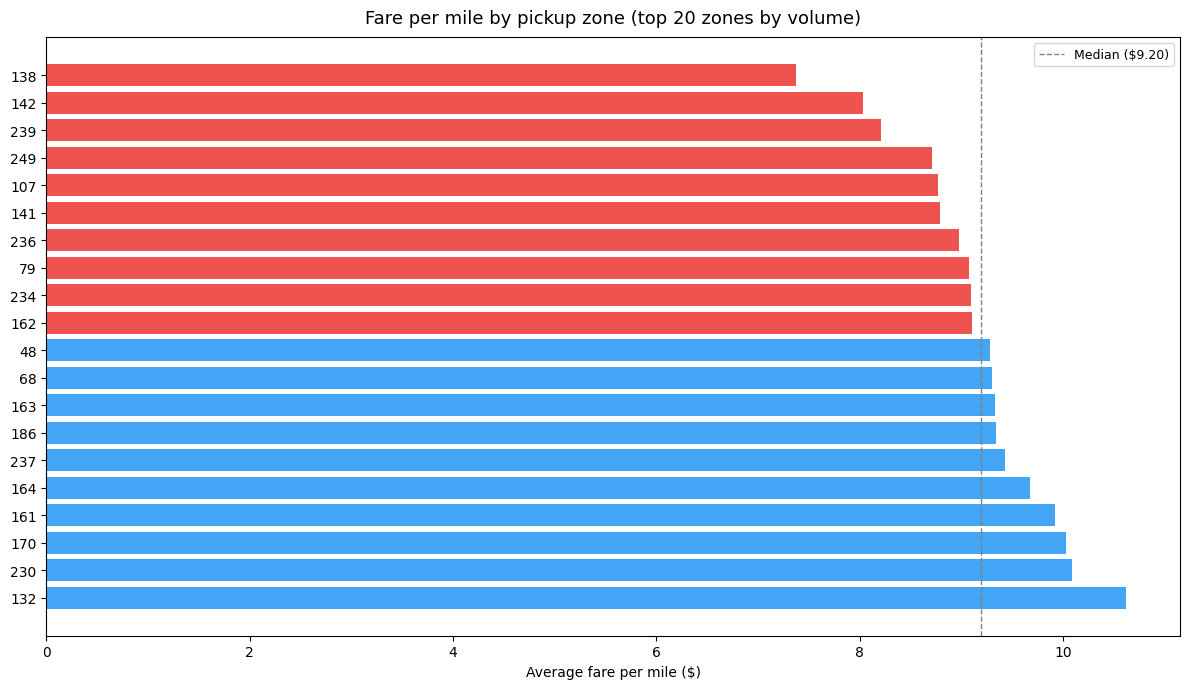

In [67]:
top_20_zones = df['PULocationID'].value_counts().head(20).index

df_filtered = df[df['PULocationID'].isin(top_20_zones)].copy()

df_filtered['fare_per_mile'] = pd.to_numeric(df_filtered['fare_per_mile'], errors='coerce')
df_filtered['fare_per_mile'] = df_filtered['fare_per_mile'].replace([np.inf, -np.inf], np.nan)

df_filtered = df_filtered.dropna(subset=['fare_per_mile'])

zone_efficiency = (
    df_filtered.groupby('PULocationID')
    .agg(
        avg_fare_per_mile=('fare_per_mile', 'mean'),
        avg_trip_distance=('trip_distance', 'mean'),
        trip_count=('fare_amount', 'count')
    )
    .reset_index()
    .sort_values('avg_fare_per_mile')
)

fig, ax = plt.subplots(figsize=(12, 7))

median_fare = zone_efficiency['avg_fare_per_mile'].median()
colors = ['#EF5350' if x < median_fare else '#42A5F5' for x in zone_efficiency['avg_fare_per_mile']]

bars = ax.barh(zone_efficiency['PULocationID'].astype(str), 
               zone_efficiency['avg_fare_per_mile'], color=colors)

ax.axvline(median_fare, color='gray', linestyle='--', linewidth=1, label=f'Median (${median_fare:.2f})')
ax.set_title('Fare per mile by pickup zone (top 20 zones by volume)', fontsize=13, pad=10)
ax.set_xlabel('Average fare per mile ($)')
ax.legend(fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('q3_fare_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()